In [1]:
# OS
import os

# Numerical and data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Imputation
from sklearn.impute import KNNImputer

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering

# Decomposition
from sklearn.decomposition import TruncatedSVD

# Evaluation metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


os.listdir()

['Data',
 'Code for project.ipynb',
 '.ipynb_checkpoints',
 'lstm_flowchart_with_decisions',
 'Dataset_scenario_2.csv',
 'Dataset_scenario_1.csv',
 'cookfarm_grids.csv',
 'lstm_flowchart.png',
 'Untitled.ipynb',
 'dataset_position_scenario_max_prof_50_dist_max.txt',
 'Untitled1.ipynb',
 'Samuel_Appenteng_Codes_1.ipynb',
 'Dataset_scenario_3.csv',
 'lstm_flowchart_with_decisions.png',
 'Samuel_Appenteng_Codes_2.ipynb',
 'Proposed_Models.ipynb',
 'lstm_flowchart']

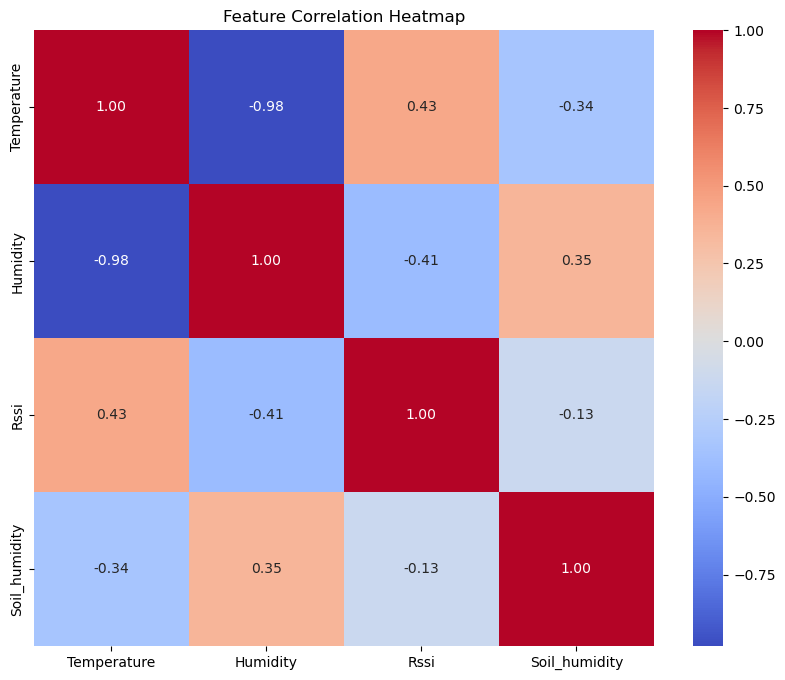

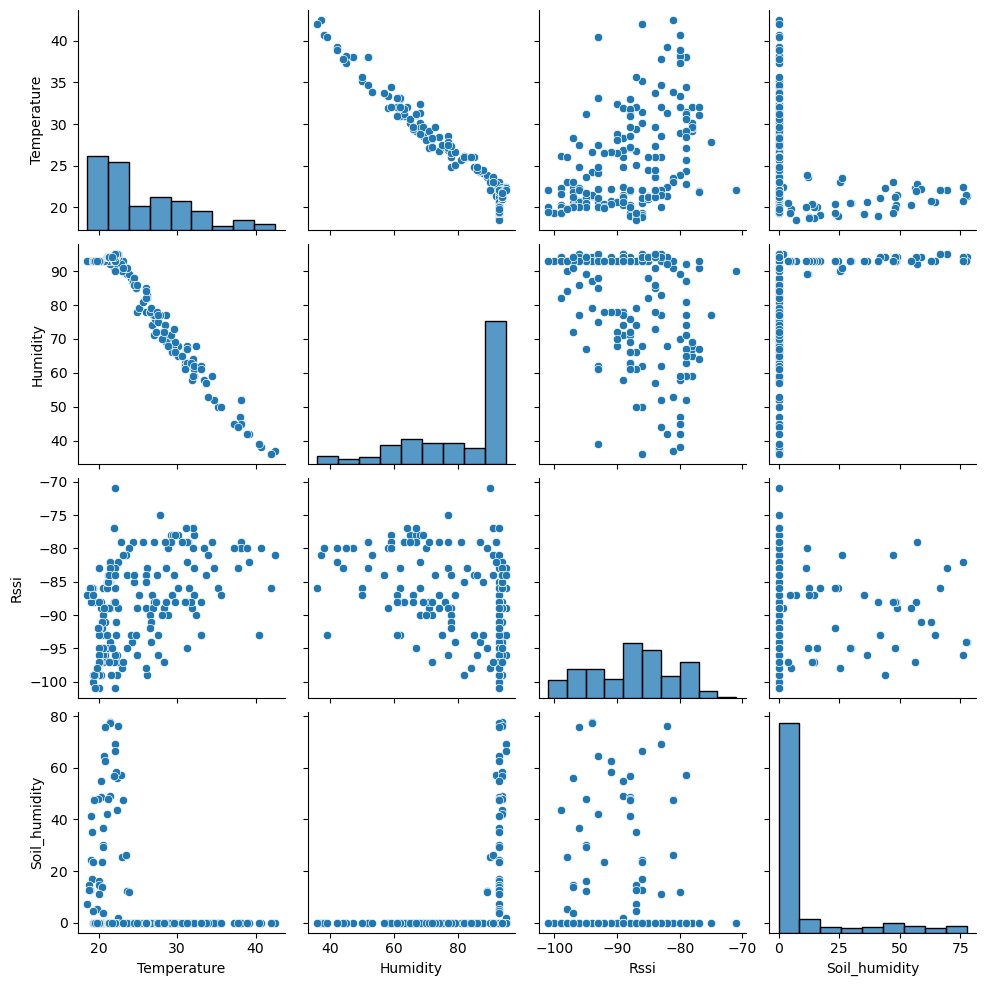

In [2]:
# Load your dataset
df = pd.read_csv("Dataset_scenario_3.csv")
df = df[['Temperature','Humidity','Rssi','Soil_humidity']]

# Drop non-numeric columns if any
df_numeric = df.select_dtypes(include=[float, int])

# Compute correlation matrix
corr_matrix = df_numeric.corr()

# Display the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Optional: Show pairplot to visualize feature relationships
sns.pairplot(df_numeric)
plt.show()


## SVD-PCA

In [3]:
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def svd_pca_impute(df, variance_threshold=0.85, max_iter=20, tol=1e-4):
    X = df.copy().to_numpy()
    missing_mask = np.isnan(X)

    # Step 1: Initial column mean imputation
    X_filled = X.copy()
    col_means = np.nanmean(X_filled, axis=0)
    inds = np.where(np.isnan(X_filled))
    X_filled[inds] = np.take(col_means, inds[1])  # column-wise imputation

    # Step 2: Standardize (optional but recommended for PCA/SVD)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_filled)

    for iteration in range(max_iter):
        X_old = X_scaled.copy()

        # Step 3: Truncated SVD
        svd = TruncatedSVD(n_components=min(X_scaled.shape) - 1, random_state=42)
        X_svd = svd.fit_transform(X_scaled)
        explained_var = np.cumsum(svd.explained_variance_ratio_)
        k = np.searchsorted(explained_var, variance_threshold) + 1

        # Step 4: Reconstruct with top-k components
        V_k = svd.components_[:k, :]
        X_reconstructed = X_svd[:, :k] @ V_k

        # Step 5: Update only missing entries
        X_scaled[missing_mask] = X_reconstructed[missing_mask]

        # Step 6: Check convergence
        diff = np.linalg.norm(X_scaled - X_old) / np.linalg.norm(X_old)
        print(f"Iteration {iteration+1}, relative change: {diff:.6f}")
        if diff < tol:
            break

    # Step 7: Inverse transform to original scale
    X_imputed = scaler.inverse_transform(X_scaled)
    return pd.DataFrame(X_imputed, columns=df.columns), missing_mask

def evaluate_imputation(original_df, imputed_df, missing_mask):
    # Normalize both for metric evaluation
    scaler = MinMaxScaler()
    original_scaled = scaler.fit_transform(original_df)
    imputed_scaled = scaler.transform(imputed_df)

    for i, col in enumerate(original_df.columns):
        true_vals = original_scaled[:, i]
        pred_vals = imputed_scaled[:, i]
        mask = missing_mask[:, i]

        print(f"\n{col} (Metrics on Normalized [0,1] Scale):")
        print(f"  [All_R2] {r2_score(true_vals, pred_vals):.4f}")
        print(f"  [All_MSE] {mean_squared_error(true_vals, pred_vals):.4f}")
        print(f"  [All_MAE] {mean_absolute_error(true_vals, pred_vals):.4f}")
        print(f"  [Missing_R2] {r2_score(true_vals[mask], pred_vals[mask]):.4f}")
        print(f"  [Missing_MSE] {mean_squared_error(true_vals[mask], pred_vals[mask]):.4f}")
        print(f"  [Missing_MAE] {mean_absolute_error(true_vals[mask], pred_vals[mask]):.4f}")

# === Main Example ===
if __name__ == "__main__":
    # Load original data
    data = pd.read_csv("Dataset_scenario_3.csv")
    data = data[['Temperature', 'Humidity', 'Rssi', 'Soil_humidity']]  # Adjust as needed

    # Introduce missing values
    rng = np.random.RandomState(42)
    data_missing = data.copy()
    mask = rng.rand(*data.shape) < 0.2
    data_missing[mask] = np.nan

    # Impute on original scale
    df_imputed, missing_mask = svd_pca_impute(data_missing)
    
    print("original data")
    print(data)

    # Display some values
    print("\nOriginal Data with Missing Values:")
    print(data_missing)
    
    df_imputed[np.abs(df_imputed) < 1e-10] = 0

    print("\nImputed Data (Original Scale):")
    print(df_imputed)

    # Evaluate on normalized scale
    evaluate_imputation(data, df_imputed, missing_mask)


Iteration 1, relative change: 0.184727
Iteration 2, relative change: 0.091693
Iteration 3, relative change: 0.045987
Iteration 4, relative change: 0.023975
Iteration 5, relative change: 0.013307
Iteration 6, relative change: 0.008026
Iteration 7, relative change: 0.005263
Iteration 8, relative change: 0.003679
Iteration 9, relative change: 0.002679
Iteration 10, relative change: 0.002007
Iteration 11, relative change: 0.001544
Iteration 12, relative change: 0.001224
Iteration 13, relative change: 0.001009
Iteration 14, relative change: 0.000871
Iteration 15, relative change: 0.000785
Iteration 16, relative change: 0.000736
Iteration 17, relative change: 0.000709
Iteration 18, relative change: 0.000695
Iteration 19, relative change: 0.000690
Iteration 20, relative change: 0.000689
original data
     Temperature  Humidity  Rssi  Soil_humidity
0           30.1      68.0   -86            0.0
1           28.3      71.0   -89            0.0
2           30.1      65.0   -78            0.0
3  

## Kmean+KNN

Missing values per column:
Temperature      45
Humidity         33
Rssi             36
Soil_humidity    39
dtype: int64

Processing feature: Temperature

Processing feature: Humidity

Processing feature: Rssi

Processing feature: Soil_humidity

--- Evaluation Metrics (All Data Points & Only Imputed Entries, Scaled to [0,1]) ---

Temperature (Scaled to [0,1]):
  [All]       R² Score: 0.8746
  [All]       MSE: 0.0070
  [All]       MAE: 0.0274
  [Missing]   R² Score: 0.4442
  [Missing]   MSE: 0.0297
  [Missing]   MAE: 0.1169

Humidity (Scaled to [0,1]):
  [All]       R² Score: 0.8330
  [All]       MSE: 0.0119
  [All]       MAE: 0.0356
  [Missing]   R² Score: -0.0333
  [Missing]   MSE: 0.0691
  [Missing]   MAE: 0.2070

Rssi (Scaled to [0,1]):
  [All]       R² Score: 0.7647
  [All]       MSE: 0.0111
  [All]       MAE: 0.0359
  [Missing]   R² Score: -0.1127
  [Missing]   MSE: 0.0592
  [Missing]   MAE: 0.1917

Soil_humidity (Scaled to [0,1]):
  [All]       R² Score: 0.8587
  [All]       MSE: 

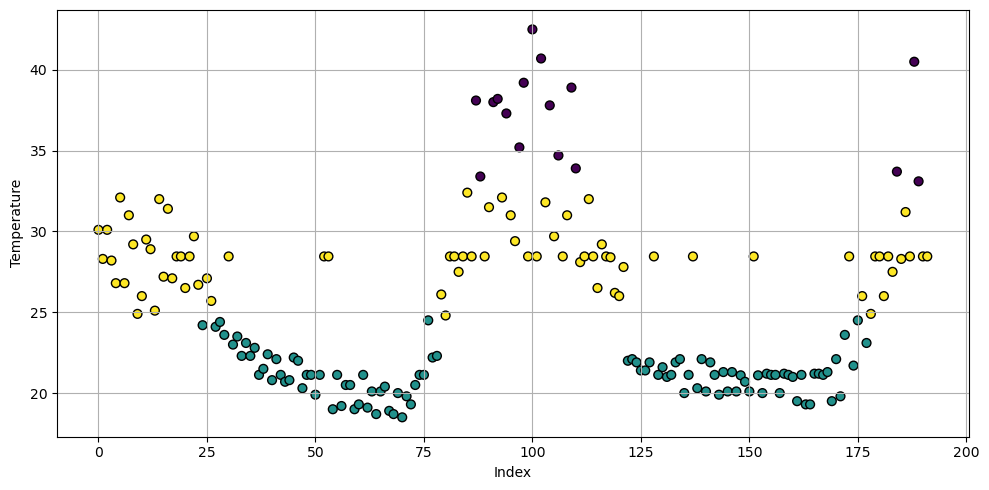

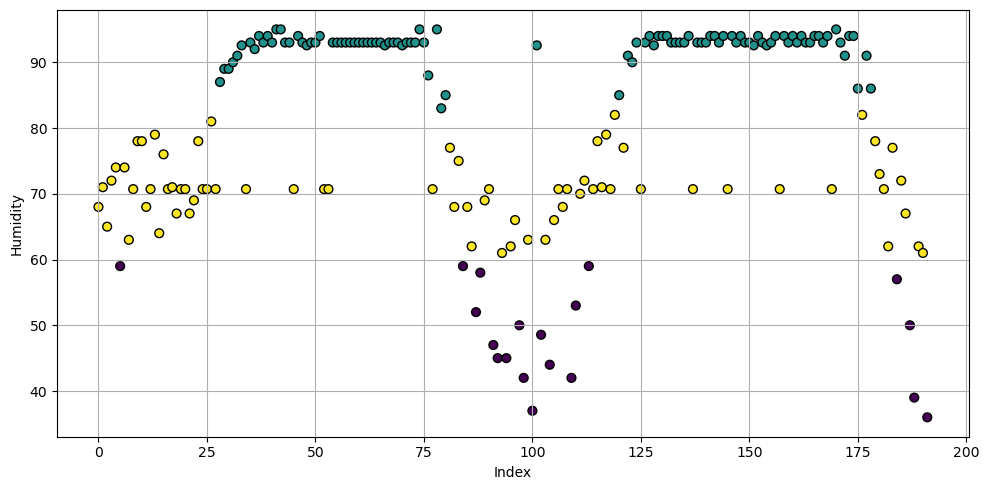

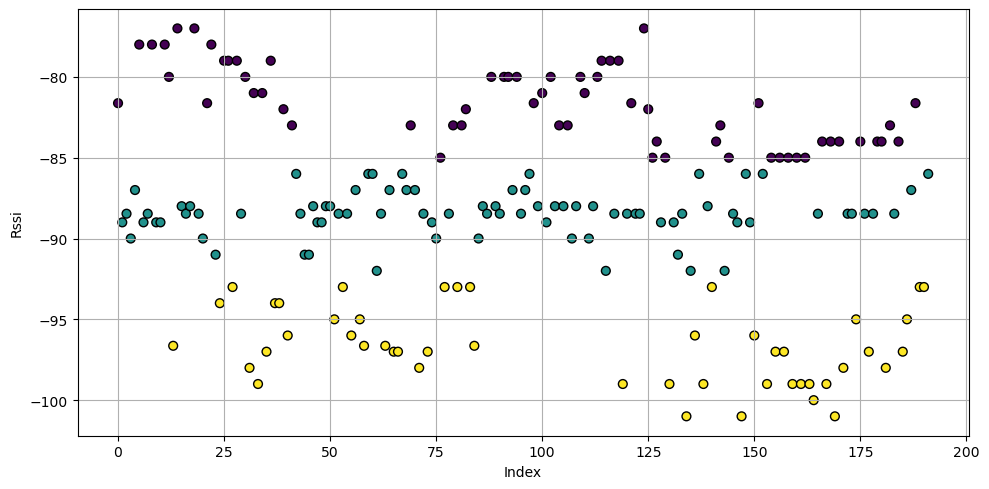

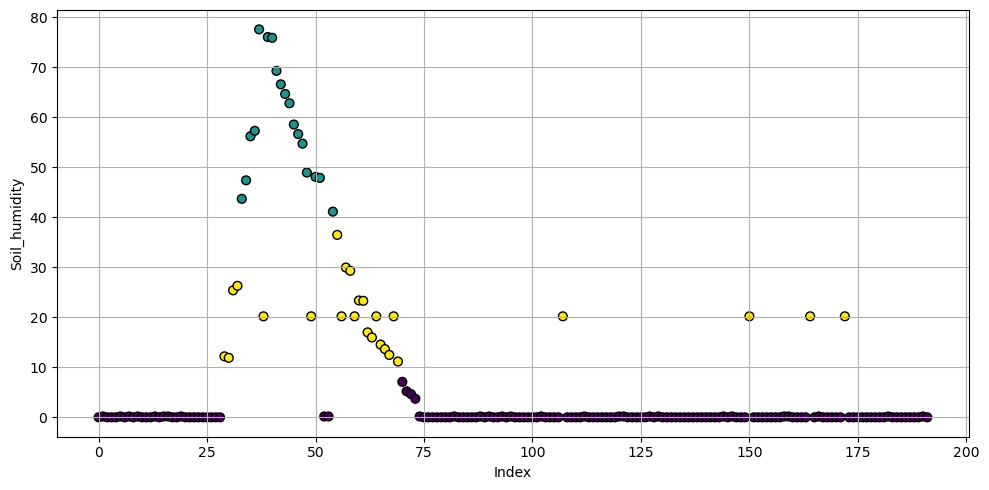


--- Sample: Data with Missing Values ---
   Temperature  Humidity  Rssi  Soil_humidity
0         30.1      68.0   NaN            0.0
1         28.3      71.0 -89.0            NaN
2         30.1      65.0   NaN            0.0
3         28.2      72.0 -90.0            0.0
4         26.8      74.0 -87.0            0.0

--- Sample: Final Imputed Data ---
   Temperature  Humidity       Rssi  Soil_humidity
0         30.1      68.0 -81.625000        0.00000
1         28.3      71.0 -89.000000        0.17225
2         30.1      65.0 -88.464286        0.00000
3         28.2      72.0 -90.000000        0.00000
4         26.8      74.0 -87.000000        0.00000


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Step 1: Introduce missing values ---
def introduce_missing_values(df, missing_rate=0.2, random_state=42):
    np.random.seed(random_state)
    data_array = df.to_numpy().copy()
    n_total = data_array.size
    n_missing = int(missing_rate * n_total)
    flat_indices = np.random.choice(n_total, n_missing, replace=False)
    data_array.ravel()[flat_indices] = np.nan
    missing_mask = np.isnan(data_array)
    return pd.DataFrame(data_array, columns=df.columns), missing_mask

# --- Load dataset ---
data = pd.read_csv("Dataset_scenario_3.csv")
data = data[['Temperature', 'Humidity', 'Rssi', 'Soil_humidity']]
original_data = data.copy()

# --- Only numeric ---
data_numeric = data.select_dtypes(include=[np.number])
df_missing, missing_mask = introduce_missing_values(data_numeric, missing_rate=0.2)
print(f"Missing values per column:\n{df_missing.isna().sum()}")

# --- Step 2: Initial global KNN Imputation ---
initial_imputer = KNNImputer(n_neighbors=5)
df_initial_imputed = pd.DataFrame(initial_imputer.fit_transform(df_missing), columns=df_missing.columns)

# --- Step 3: Column-wise Clustering and Cluster-wise KNN Imputation ---
df_clusterwise_imputed = df_missing.copy()
scaler = StandardScaler()

for feature in df_missing.columns:
    print(f"\nProcessing feature: {feature}")

    # Use initial imputation of the feature
    feature_data = df_initial_imputed[[feature]].copy()
    feature_scaled = scaler.fit_transform(feature_data)

    # Cluster into 3 groups based on the imputed values
    kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(feature_scaled)

    # Store cluster labels for visualization later
    df_clusterwise_imputed[f'{feature}_Cluster'] = cluster_labels

    # Impute within each cluster
    for cluster_id in range(3):
        cluster_indices = df_clusterwise_imputed[df_clusterwise_imputed[f'{feature}_Cluster'] == cluster_id].index
        sub_df = df_clusterwise_imputed.loc[cluster_indices, [feature]]

        if sub_df[feature].isna().sum() == 0:
            continue  # nothing to impute

        knn = KNNImputer(n_neighbors=3)
        sub_imputed = knn.fit_transform(sub_df)

        # Update the main dataframe
        df_clusterwise_imputed.loc[cluster_indices, feature] = sub_imputed

# Drop cluster columns to keep only imputed data
df_clusterwise_imputed = df_clusterwise_imputed[df_missing.columns]

# --- Step 4: Evaluation Metrics (on [0,1] scale only for metrics) ---
scaler = MinMaxScaler()
original_scaled = pd.DataFrame(scaler.fit_transform(original_data), columns=original_data.columns)
imputed_scaled = pd.DataFrame(scaler.transform(df_clusterwise_imputed), columns=df_clusterwise_imputed.columns)

print("\n--- Evaluation Metrics (All Data Points & Only Imputed Entries, Scaled to [0,1]) ---")
for i, feature in enumerate(df_missing.columns):
    # All positions
    y_true_all = original_scaled[feature]
    y_pred_all = imputed_scaled[feature]

    # Only imputed positions
    mask = missing_mask[:, i]
    y_true_missing = original_scaled.loc[mask, feature]
    y_pred_missing = imputed_scaled.loc[mask, feature]

    print(f"\n{feature} (Scaled to [0,1]):")
    print(f"  [All]       R² Score: {r2_score(y_true_all, y_pred_all):.4f}")
    print(f"  [All]       MSE: {mean_squared_error(y_true_all, y_pred_all):.4f}")
    print(f"  [All]       MAE: {mean_absolute_error(y_true_all, y_pred_all):.4f}")
    if mask.sum() > 0:
        print(f"  [Missing]   R² Score: {r2_score(y_true_missing, y_pred_missing):.4f}")
        print(f"  [Missing]   MSE: {mean_squared_error(y_true_missing, y_pred_missing):.4f}")
        print(f"  [Missing]   MAE: {mean_absolute_error(y_true_missing, y_pred_missing):.4f}")
    else:
        print("  [Missing]   No imputed values for this feature.")

# --- Step 5: Visualize clustering per feature ---
for feature in df_missing.columns:
    feature_data = df_initial_imputed[[feature]].copy()
    feature_scaled = scaler.fit_transform(feature_data)

    kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(feature_scaled)

    plt.figure(figsize=(10, 5))
    plt.scatter(np.arange(len(df_clusterwise_imputed)), df_clusterwise_imputed[feature],
                c=cluster_labels, cmap='viridis', s=40, edgecolor='k')
#     plt.title(f'{feature} - Final Imputed Values with Cluster Coloring')
    plt.xlabel('Index')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.grid(True)
    plt.show()

# --- Step 6: Show data previews ---
print("\n--- Sample: Data with Missing Values ---")
print(df_missing.head())

print("\n--- Sample: Final Imputed Data ---")
print(df_clusterwise_imputed.head())


## Agglomerative+KNN

Missing values per column:
Temperature      45
Humidity         33
Rssi             36
Soil_humidity    39
dtype: int64

Processing feature: Temperature

Processing feature: Humidity

Processing feature: Rssi

Processing feature: Soil_humidity

--- Evaluation Metrics (All Data Points & Only Imputed Entries, Scaled to [0,1]) ---

Temperature (Scaled to [0,1]):
  [All]       R² Score: 0.8579
  [All]       MSE: 0.0079
  [All]       MAE: 0.0302
  [Missing]   R² Score: 0.3704
  [Missing]   MSE: 0.0336
  [Missing]   MAE: 0.1288

Humidity (Scaled to [0,1]):
  [All]       R² Score: 0.8246
  [All]       MSE: 0.0125
  [All]       MAE: 0.0360
  [Missing]   R² Score: -0.0853
  [Missing]   MSE: 0.0726
  [Missing]   MAE: 0.2096

Rssi (Scaled to [0,1]):
  [All]       R² Score: 0.7377
  [All]       MSE: 0.0124
  [All]       MAE: 0.0400
  [Missing]   R² Score: -0.2402
  [Missing]   MSE: 0.0660
  [Missing]   MAE: 0.2134

Soil_humidity (Scaled to [0,1]):
  [All]       R² Score: 0.8425
  [All]       MSE: 

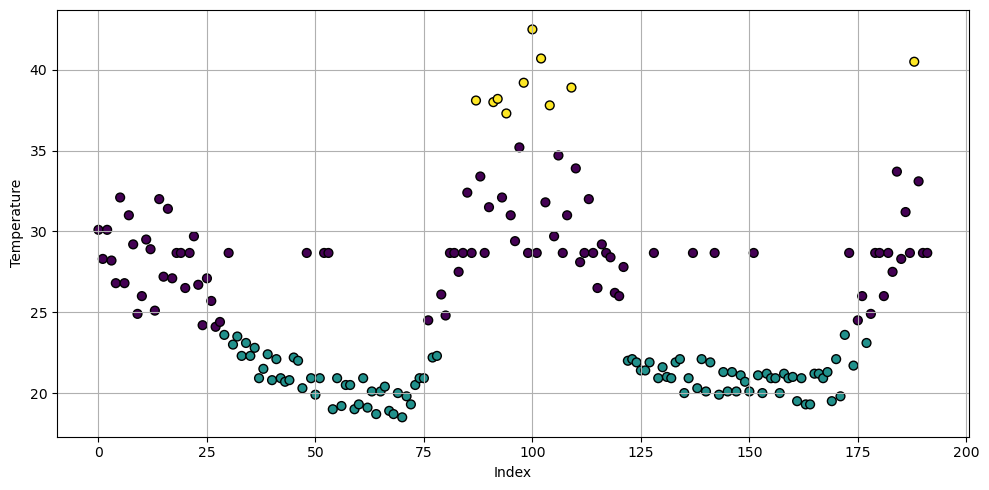

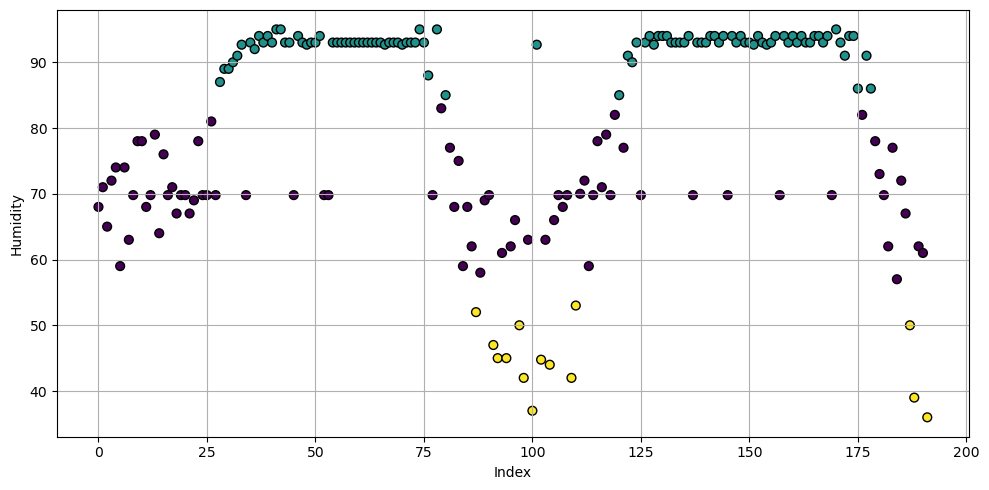

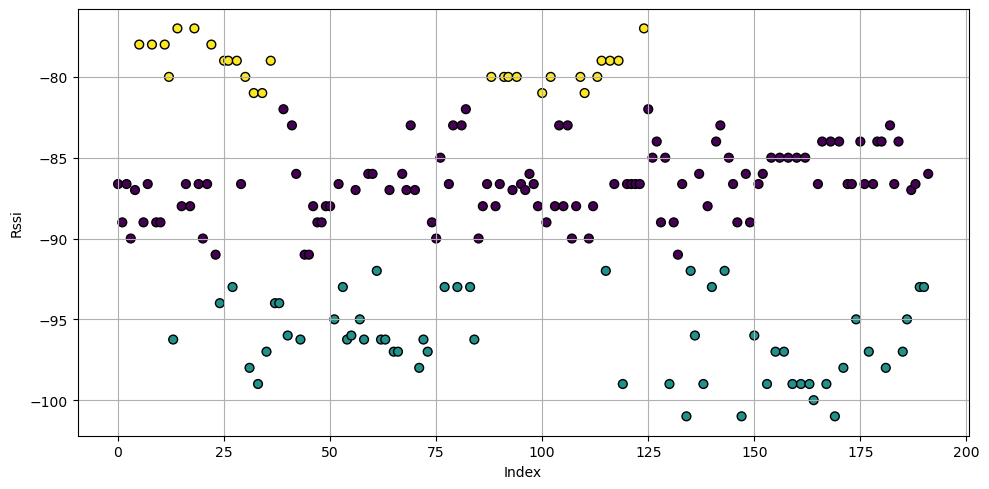

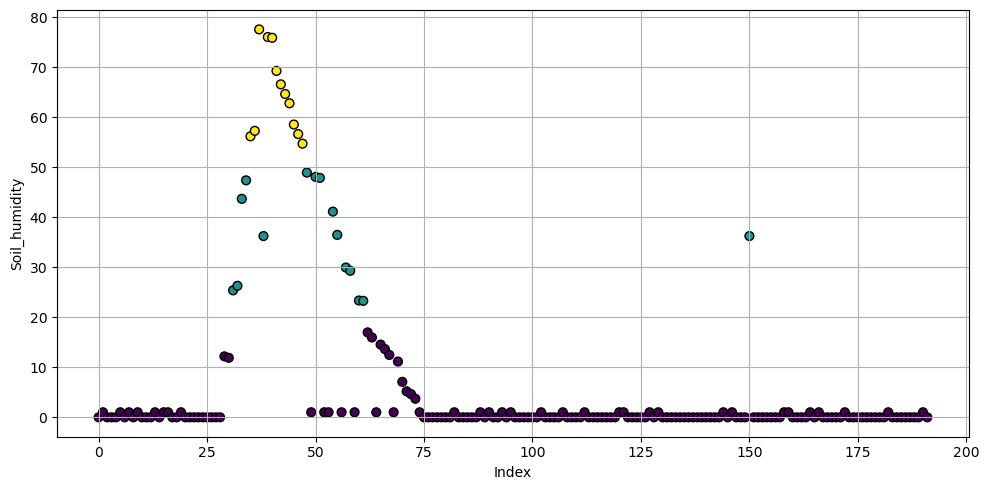


--- Sample: Data with Missing Values ---
   Temperature  Humidity  Rssi  Soil_humidity
0         30.1      68.0   NaN            0.0
1         28.3      71.0 -89.0            NaN
2         30.1      65.0   NaN            0.0
3         28.2      72.0 -90.0            0.0
4         26.8      74.0 -87.0            0.0

--- Sample: Final Imputed Data ---
   Temperature  Humidity      Rssi  Soil_humidity
0         30.1      68.0 -86.62963       0.000000
1         28.3      71.0 -89.00000       1.012188
2         30.1      65.0 -86.62963       0.000000
3         28.2      72.0 -90.00000       0.000000
4         26.8      74.0 -87.00000       0.000000


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.cluster import AgglomerativeClustering  # replaced here
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Step 1: Introduce missing values ---
def introduce_missing_values(df, missing_rate=0.2, random_state=42):
    np.random.seed(random_state)
    data_array = df.to_numpy().copy()
    n_total = data_array.size
    n_missing = int(missing_rate * n_total)
    flat_indices = np.random.choice(n_total, n_missing, replace=False)
    data_array.ravel()[flat_indices] = np.nan
    missing_mask = np.isnan(data_array)
    return pd.DataFrame(data_array, columns=df.columns), missing_mask

# --- Load dataset ---
data = pd.read_csv("Dataset_scenario_3.csv")
data = data[['Temperature', 'Humidity', 'Rssi', 'Soil_humidity']]
original_data = data.copy()

# --- Only numeric ---
data_numeric = data.select_dtypes(include=[np.number])
df_missing, missing_mask = introduce_missing_values(data_numeric, missing_rate=0.2)
print(f"Missing values per column:\n{df_missing.isna().sum()}")

# --- Step 2: Initial global KNN Imputation ---
initial_imputer = KNNImputer(n_neighbors=5)
df_initial_imputed = pd.DataFrame(initial_imputer.fit_transform(df_missing), columns=df_missing.columns)

# --- Step 3: Column-wise Clustering and Cluster-wise KNN Imputation ---
df_clusterwise_imputed = df_missing.copy()
scaler = StandardScaler()

for feature in df_missing.columns:
    print(f"\nProcessing feature: {feature}")

    # Use initial imputation of the feature
    feature_data = df_initial_imputed[[feature]].copy()
    feature_scaled = scaler.fit_transform(feature_data)

    # Agglomerative Clustering instead of KMeans
    agglo = AgglomerativeClustering(n_clusters=3)
    cluster_labels = agglo.fit_predict(feature_scaled)

    # Store cluster labels for visualization later
    df_clusterwise_imputed[f'{feature}_Cluster'] = cluster_labels

    # Impute within each cluster
    for cluster_id in range(3):
        cluster_indices = df_clusterwise_imputed[df_clusterwise_imputed[f'{feature}_Cluster'] == cluster_id].index
        sub_df = df_clusterwise_imputed.loc[cluster_indices, [feature]]

        if sub_df[feature].isna().sum() == 0:
            continue  # nothing to impute

        knn = KNNImputer(n_neighbors=3)
        sub_imputed = knn.fit_transform(sub_df)

        # Update the main dataframe
        df_clusterwise_imputed.loc[cluster_indices, feature] = sub_imputed

# Drop cluster columns to keep only imputed data
df_clusterwise_imputed = df_clusterwise_imputed[df_missing.columns]

# --- Step 4: Evaluation Metrics (on [0,1] scale only for metrics) ---
scaler = MinMaxScaler()
original_scaled = pd.DataFrame(scaler.fit_transform(original_data), columns=original_data.columns)
imputed_scaled = pd.DataFrame(scaler.transform(df_clusterwise_imputed), columns=df_clusterwise_imputed.columns)

print("\n--- Evaluation Metrics (All Data Points & Only Imputed Entries, Scaled to [0,1]) ---")
for i, feature in enumerate(df_missing.columns):
    # All positions
    y_true_all = original_scaled[feature]
    y_pred_all = imputed_scaled[feature]

    # Only imputed positions
    mask = missing_mask[:, i]
    y_true_missing = original_scaled.loc[mask, feature]
    y_pred_missing = imputed_scaled.loc[mask, feature]

    print(f"\n{feature} (Scaled to [0,1]):")
    print(f"  [All]       R² Score: {r2_score(y_true_all, y_pred_all):.4f}")
    print(f"  [All]       MSE: {mean_squared_error(y_true_all, y_pred_all):.4f}")
    print(f"  [All]       MAE: {mean_absolute_error(y_true_all, y_pred_all):.4f}")
    if mask.sum() > 0:
        print(f"  [Missing]   R² Score: {r2_score(y_true_missing, y_pred_missing):.4f}")
        print(f"  [Missing]   MSE: {mean_squared_error(y_true_missing, y_pred_missing):.4f}")
        print(f"  [Missing]   MAE: {mean_absolute_error(y_true_missing, y_pred_missing):.4f}")
    else:
        print("  [Missing]   No imputed values for this feature.")

# --- Step 5: Visualize clustering per feature ---
for feature in df_missing.columns:
    feature_data = df_initial_imputed[[feature]].copy()
    feature_scaled = scaler.fit_transform(feature_data)

    agglo = AgglomerativeClustering(n_clusters=3)
    cluster_labels = agglo.fit_predict(feature_scaled)

    plt.figure(figsize=(10, 5))
    plt.scatter(np.arange(len(df_clusterwise_imputed)), df_clusterwise_imputed[feature],
                c=cluster_labels, cmap='viridis', s=40, edgecolor='k')
#     plt.title(f'{feature} - Final Imputed Values with Cluster Coloring (Agglomerative)')
    plt.xlabel('Index')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.grid(True)
    plt.show()

# --- Step 6: Show data previews ---
print("\n--- Sample: Data with Missing Values ---")
print(df_missing.head())

print("\n--- Sample: Final Imputed Data ---")
print(df_clusterwise_imputed.head())


In [6]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.cluster.hierarchy import dendrogram, linkage
# from sklearn.preprocessing import StandardScaler

# def plot_dendrogram(feature_data, feature_name, method='ward', n_points=10):
#     """
#     Plot dendrogram for the first n_points of a single feature column.

#     Parameters:
#     - feature_data: 1D numpy array or pandas Series
#     - feature_name: string, name of the feature
#     - method: linkage method, default 'ward'
#     - n_points: number of data points to consider from the start
#     """

#     # Slice to first n_points
#     feature_slice = feature_data.iloc[:n_points]

#     # Reshape to 2D (n_samples, 1)
#     X = feature_slice.values.reshape(-1, 1)

#     # Standardize
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X)

#     # Compute linkage matrix
#     Z = linkage(X_scaled, method=method)

#     # Plot dendrogram
#     plt.figure(figsize=(10, 6))
#     dendrogram(Z, leaf_rotation=90., leaf_font_size=8.)
# #     plt.title(f'Dendrogram for {feature_name} (first {n_points} points, method={method})')
#     plt.xlabel('Sample index')
#     plt.ylabel('Distance')
#     plt.show()

# # Example usage for each feature column (first 10 points only)
# for feature in data.columns:
#     plot_dendrogram(data[feature], feature, n_points=10)


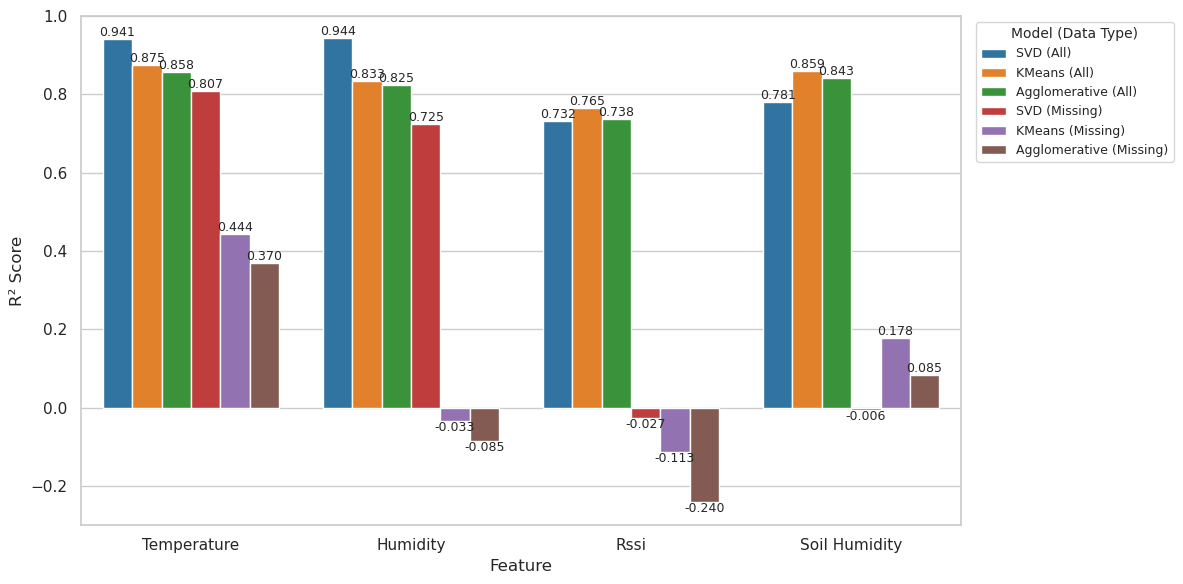

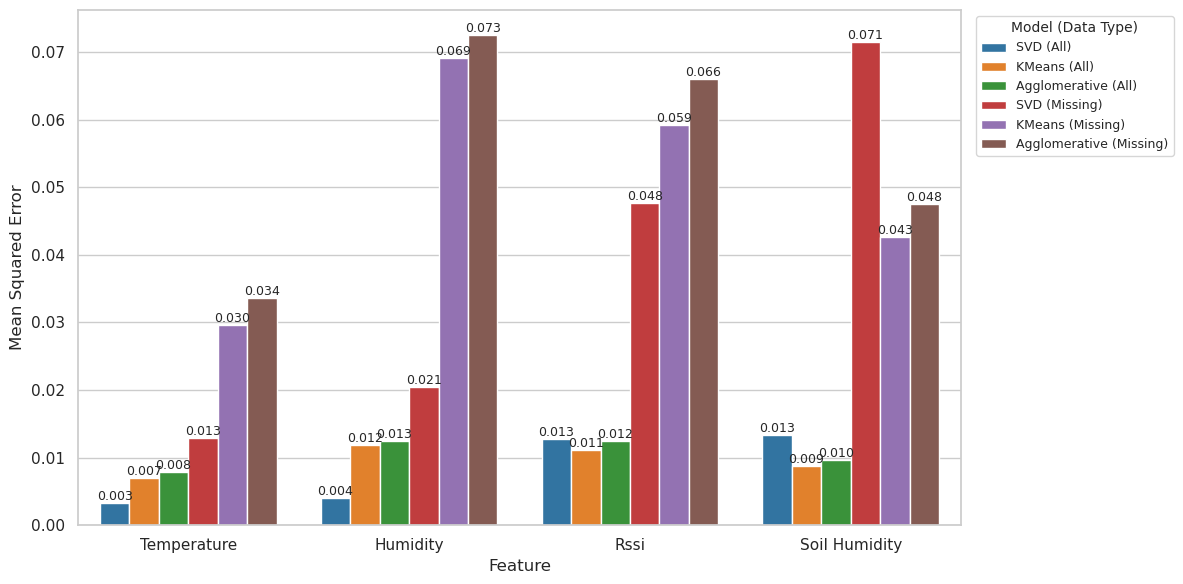

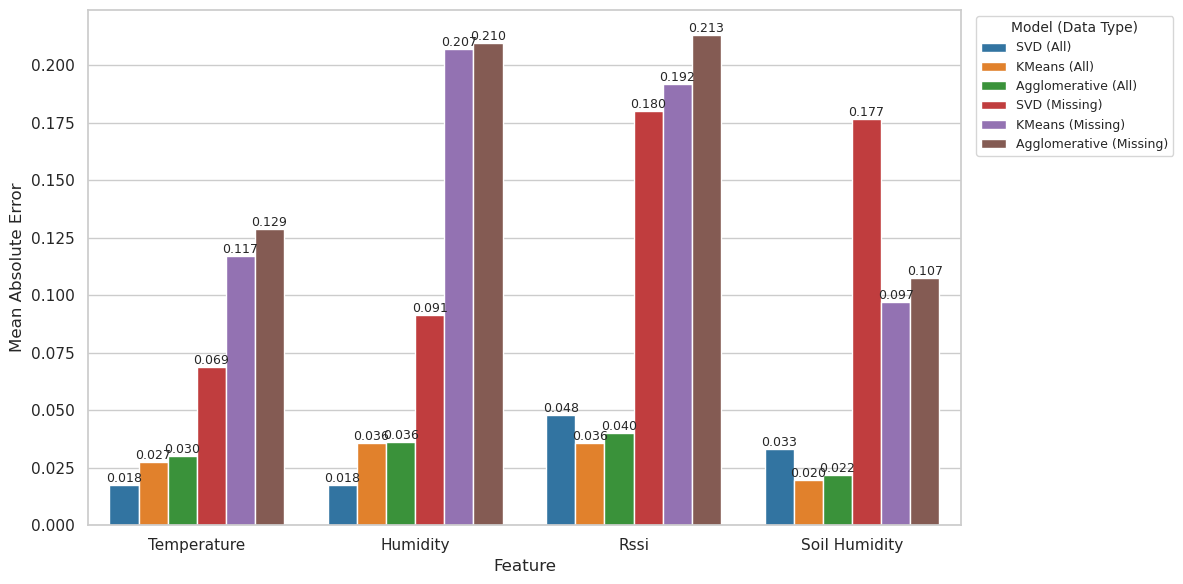

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set style and vivid color palette
sns.set(style="whitegrid", palette="tab10")

# Construct the DataFrame
data = {
    'Feature': ['Temperature']*3 + ['Humidity']*3 + ['Rssi']*3 + ['Soil Humidity']*3,
    'Method': ['SVD', 'KMeans', 'Agglomerative']*4,
    'All R²': [0.9406, 0.8746, 0.8579, 0.9444, 0.8330, 0.8246, 0.7315, 0.7647, 0.7377, 0.7812, 0.8587, 0.8425],
    'All MSE': [0.0033, 0.0070, 0.0079, 0.0040, 0.0119, 0.0125, 0.0127, 0.0111, 0.0124, 0.0134, 0.0087, 0.0096],
    'All MAE': [0.0175, 0.0274, 0.0302, 0.0176, 0.0356, 0.0360, 0.0478, 0.0359, 0.0400, 0.0331, 0.0197, 0.0218],
    'Missing R²': [0.8075, 0.4442, 0.3704, 0.7252, -0.0333, -0.0853, -0.0267, -0.1127, -0.2402, -0.0058, 0.1785, 0.0845],
    'Missing MSE': [0.0129, 0.0297, 0.0336, 0.0205, 0.0691, 0.0726, 0.0477, 0.0592, 0.0660, 0.0715, 0.0426, 0.0475],
    'Missing MAE': [0.0687, 0.1169, 0.1288, 0.0915, 0.2070, 0.2096, 0.1800, 0.1917, 0.2134, 0.1767, 0.0970, 0.1074]
}

df = pd.DataFrame(data)

# Melt the DataFrame for plotting
df_melted = pd.melt(df, id_vars=['Feature', 'Method'], var_name='MetricFull', value_name='Value')

# Split into 'DataType' and 'Metric'
df_melted[['DataType', 'Metric']] = df_melted['MetricFull'].str.split(' ', n=1, expand=True)

# Combine Method and DataType for hue
df_melted['ModelType'] = df_melted['Method'] + ' (' + df_melted['DataType'] + ')'

# Plot function with bar labels and adjusted legend
def plot_metric(metric_name, title, ylabel, ylim=None):
    plt.figure(figsize=(12, 6))
    subset = df_melted[df_melted['Metric'] == metric_name]
    ax = sns.barplot(data=subset, x='Feature', y='Value', hue='ModelType', dodge=True, errorbar=None)

    # Add values on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=9)

    plt.ylabel(ylabel)
    if ylim:
        plt.ylim(ylim)
    plt.xticks(rotation=0)

    # Smaller and moved legend
    plt.legend(
        title='Model (Data Type)',
        fontsize=9,
        title_fontsize=10,
        loc='upper left',
        bbox_to_anchor=(1.01, 1)
    )

    plt.tight_layout()
    plt.show()

# Plot each metric
plot_metric('R²', 'R² Scores by Feature and Model (All vs Missing)', 'R² Score', ylim=(-0.3, 1.0))
plot_metric('MSE', 'MSE by Feature and Model (All vs Missing)', 'Mean Squared Error')
plot_metric('MAE', 'MAE by Feature and Model (All vs Missing)', 'Mean Absolute Error')


               Final_Grade
Method                    
SVD               0.570062
KMeans            0.429806
Agglomerative     0.347688


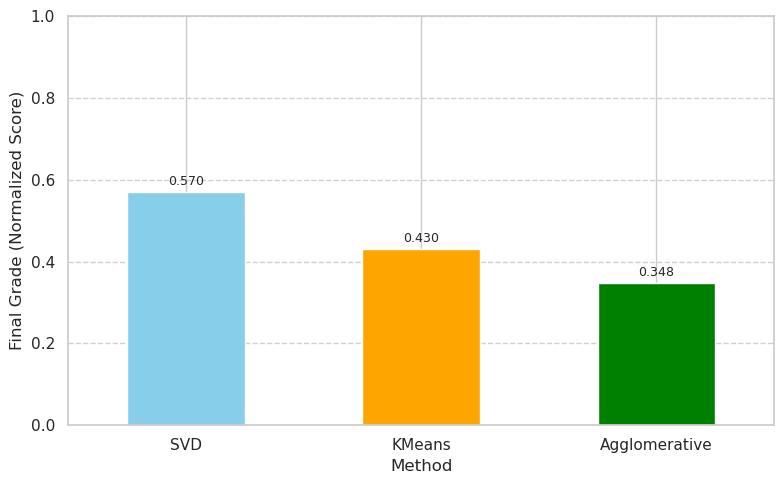

In [8]:
import matplotlib.pyplot as plt

metrics = {
    'All R²': True,
    'All MSE': False,
    'All MAE': False,
    'Missing R²': True,
    'Missing MSE': False,
    'Missing MAE': False
}

# Normalize all metrics
for metric, higher_is_better in metrics.items():
    col = df[metric]
    min_val = col.min()
    max_val = col.max()
    if max_val - min_val == 0:
        df[metric + '_norm'] = 1.0
    else:
        if higher_is_better:
            df[metric + '_norm'] = (col - min_val) / (max_val - min_val)
        else:
            df[metric + '_norm'] = (max_val - col) / (max_val - min_val)

# Columns of normalized metrics
norm_cols = [m + '_norm' for m in metrics.keys()]

# Compute average normalized score per method (across all features)
model_scores = df.groupby('Method')[norm_cols].mean()

# Average across all normalized metrics per model to get a final grade
model_scores['Final_Grade'] = model_scores.mean(axis=1)

# Sort by final grade descending
model_scores = model_scores.sort_values('Final_Grade', ascending=False)

print(model_scores[['Final_Grade']])

# Visualize with bar labels
plt.figure(figsize=(8, 5))
ax = model_scores['Final_Grade'].plot(kind='bar', color=['skyblue', 'orange', 'green'])
plt.ylabel('Final Grade (Normalized Score)')
# plt.title('Overall Model Grades Based on Combined Metrics')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.9)

# Add value labels on bars
for i, v in enumerate(model_scores['Final_Grade']):
    ax.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


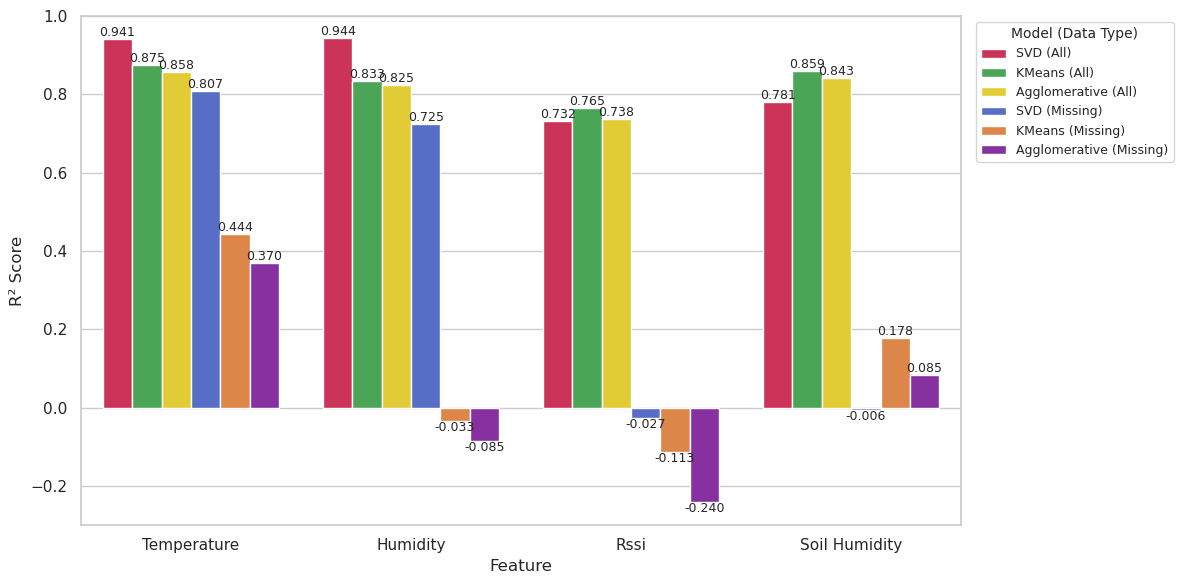

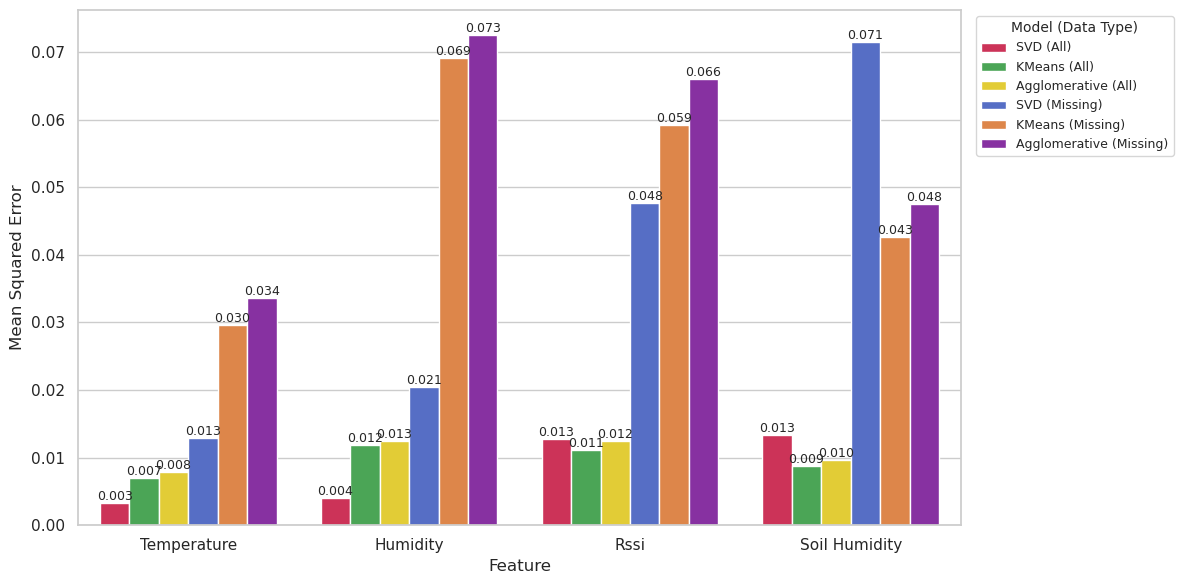

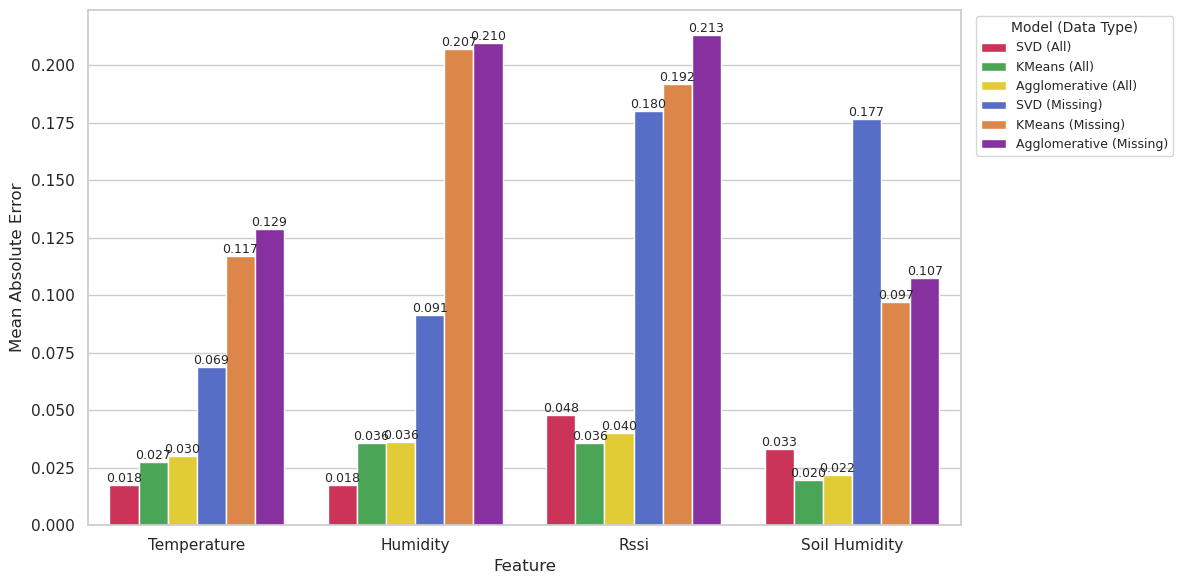

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set vibrant color palette
vibrant_palette = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8",
    "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff"
]
sns.set(style="whitegrid", palette=vibrant_palette)

# Construct the DataFrame
data = {
    'Feature': ['Temperature']*3 + ['Humidity']*3 + ['Rssi']*3 + ['Soil Humidity']*3,
    'Method': ['SVD', 'KMeans', 'Agglomerative']*4,
    'All R²': [0.9406, 0.8746, 0.8579, 0.9444, 0.8330, 0.8246, 0.7315, 0.7647, 0.7377, 0.7812, 0.8587, 0.8425],
    'All MSE': [0.0033, 0.0070, 0.0079, 0.0040, 0.0119, 0.0125, 0.0127, 0.0111, 0.0124, 0.0134, 0.0087, 0.0096],
    'All MAE': [0.0175, 0.0274, 0.0302, 0.0176, 0.0356, 0.0360, 0.0478, 0.0359, 0.0400, 0.0331, 0.0197, 0.0218],
    'Missing R²': [0.8075, 0.4442, 0.3704, 0.7252, -0.0333, -0.0853, -0.0267, -0.1127, -0.2402, -0.0058, 0.1785, 0.0845],
    'Missing MSE': [0.0129, 0.0297, 0.0336, 0.0205, 0.0691, 0.0726, 0.0477, 0.0592, 0.0660, 0.0715, 0.0426, 0.0475],
    'Missing MAE': [0.0687, 0.1169, 0.1288, 0.0915, 0.2070, 0.2096, 0.1800, 0.1917, 0.2134, 0.1767, 0.0970, 0.1074]
}

df = pd.DataFrame(data)

# Melt the DataFrame for plotting
df_melted = pd.melt(df, id_vars=['Feature', 'Method'], var_name='MetricFull', value_name='Value')

# Split into 'DataType' and 'Metric'
df_melted[['DataType', 'Metric']] = df_melted['MetricFull'].str.split(' ', n=1, expand=True)

# Combine Method and DataType for hue
df_melted['ModelType'] = df_melted['Method'] + ' (' + df_melted['DataType'] + ')'

# Plot function with vibrant colors, bar labels, and small legend
def plot_metric(metric_name, title, ylabel, ylim=None):
    plt.figure(figsize=(12, 6))
    subset = df_melted[df_melted['Metric'] == metric_name]
    ax = sns.barplot(data=subset, x='Feature', y='Value', hue='ModelType', dodge=True, errorbar=None)

    # Add values on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=9)

    plt.ylabel(ylabel)
    if ylim:
        plt.ylim(ylim)
    plt.xticks(rotation=0)

    # Small, vibrant legend moved to side
    plt.legend(
        title='Model (Data Type)',
        fontsize=9,
        title_fontsize=10,
        loc='upper left',
        bbox_to_anchor=(1.01, 1)
    )

    plt.tight_layout()
    plt.show()

# Plot each metric
plot_metric('R²', 'R² Scores by Feature and Model (All vs Missing)', 'R² Score', ylim=(-0.3, 1.0))
plot_metric('MSE', 'MSE by Feature and Model (All vs Missing)', 'Mean Squared Error')
plot_metric('MAE', 'MAE by Feature and Model (All vs Missing)', 'Mean Absolute Error')


               Final_Grade
Method                    
SVD               0.570062
KMeans            0.429806
Agglomerative     0.347688


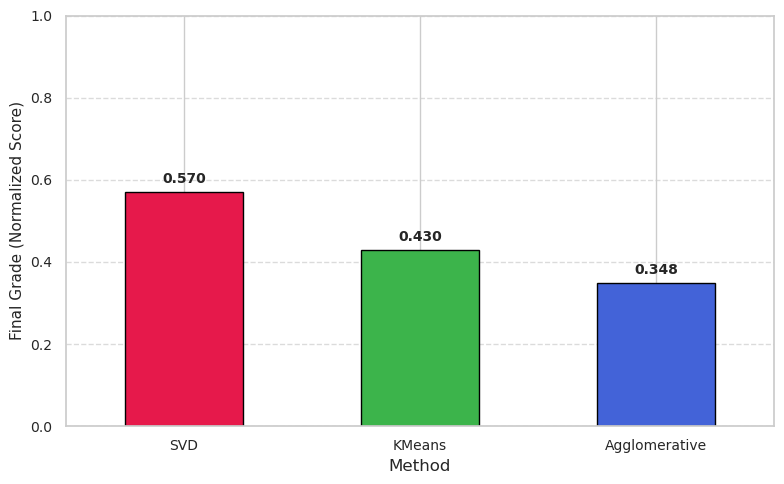

In [10]:
import matplotlib.pyplot as plt

# Define vibrant colors for the bars
bar_colors = ['#e6194b', '#3cb44b', '#4363d8']  # Red, Green, Blue

# Normalize metrics
metrics = {
    'All R²': True,
    'All MSE': False,
    'All MAE': False,
    'Missing R²': True,
    'Missing MSE': False,
    'Missing MAE': False
}

for metric, higher_is_better in metrics.items():
    col = df[metric]
    min_val, max_val = col.min(), col.max()
    if max_val - min_val == 0:
        df[metric + '_norm'] = 1.0
    else:
        if higher_is_better:
            df[metric + '_norm'] = (col - min_val) / (max_val - min_val)
        else:
            df[metric + '_norm'] = (max_val - col) / (max_val - min_val)

norm_cols = [m + '_norm' for m in metrics.keys()]
model_scores = df.groupby('Method')[norm_cols].mean()
model_scores['Final_Grade'] = model_scores.mean(axis=1)
model_scores = model_scores.sort_values('Final_Grade', ascending=False)

print(model_scores[['Final_Grade']])

# Plot
plt.figure(figsize=(8, 5))
ax = model_scores['Final_Grade'].plot(
    kind='bar',
    color=bar_colors[:len(model_scores)],
    edgecolor='black'
)
plt.ylabel('Final Grade (Normalized Score)', fontsize=11)
plt.ylim(0, 1)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels
for i, v in enumerate(model_scores['Final_Grade']):
    ax.text(i, v + 0.015, f"{v:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()



🔍 Elbow Method + Optimal k for feature: Temperature
  ✅ Approximate optimal number of clusters: 2


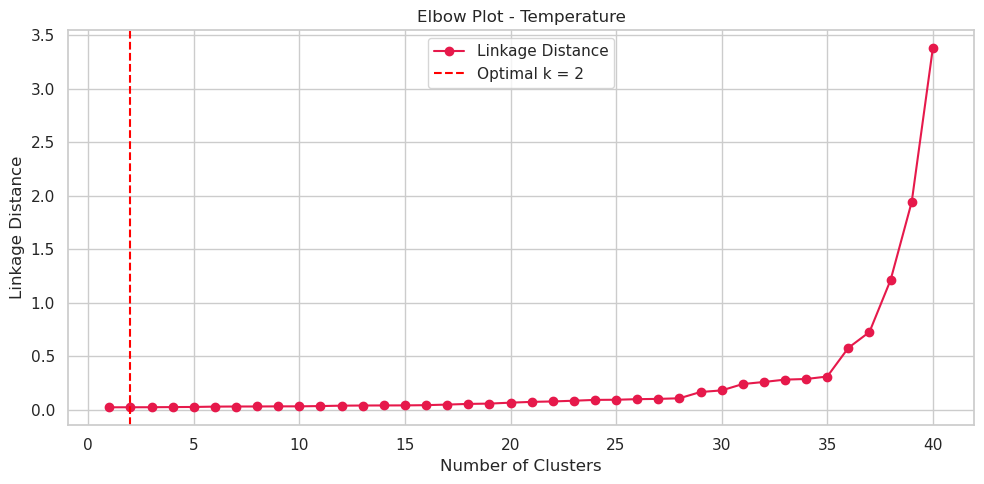


🔍 Elbow Method + Optimal k for feature: Humidity
  ✅ Approximate optimal number of clusters: 2


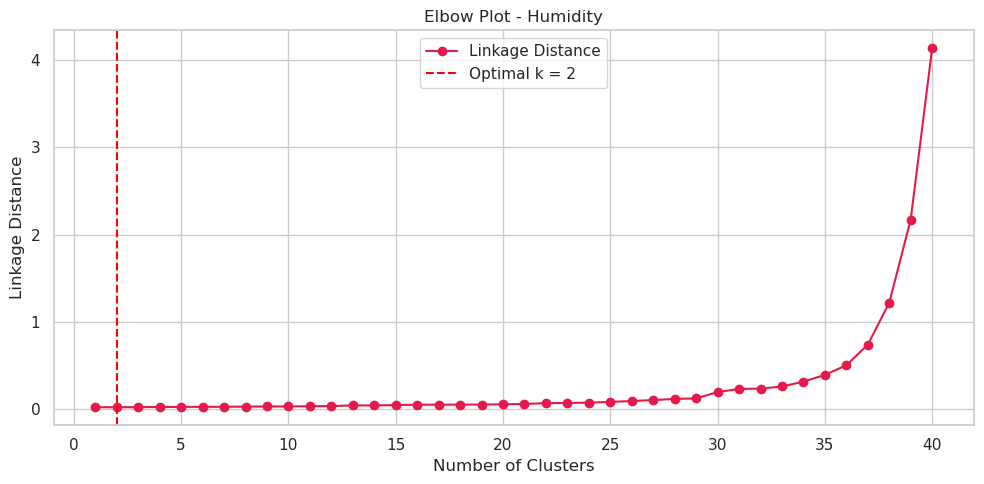


🔍 Elbow Method + Optimal k for feature: Rssi
  ✅ Approximate optimal number of clusters: 2


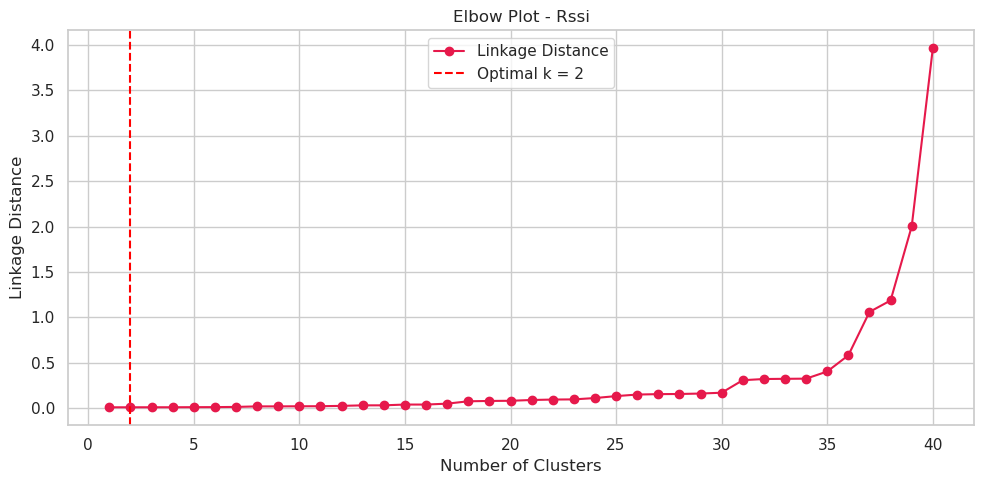


🔍 Elbow Method + Optimal k for feature: Soil_humidity
  ✅ Approximate optimal number of clusters: 2


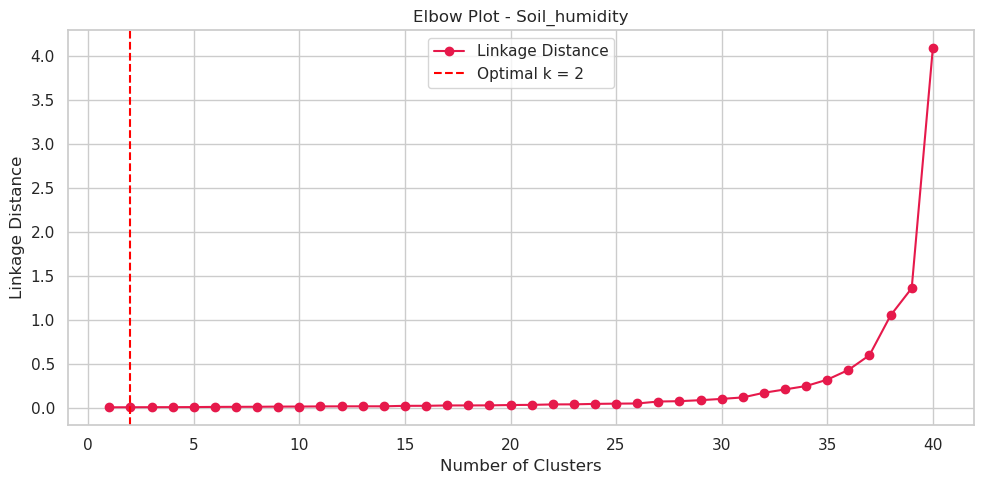


📊 Optimal k values per feature:
  - Temperature: 2
  - Humidity: 2
  - Rssi: 2
  - Soil_humidity: 2


In [13]:
from scipy.cluster.hierarchy import linkage
import numpy as np
import matplotlib.pyplot as plt

optimal_k_dict = {}

for feature in df_missing.columns:
    print(f"\n🔍 Elbow Method + Optimal k for feature: {feature}")
    
    # Step 1: Scale the data
    feature_data = df_initial_imputed[[feature]].copy()
    feature_scaled = scaler.fit_transform(feature_data)

    # Step 2: Compute linkage
    Z = linkage(feature_scaled, method='ward')

    # Step 3: Use last N linkage distances
    last = Z[-40:, 2]  # last 40 merge distances
    num_clusters = range(len(last), 0, -1)  # from more clusters to fewer

    # Step 4: Approximate the elbow using second derivative
    reversed_distances = last[::-1]
    diff1 = np.diff(reversed_distances)
    diff2 = np.diff(diff1)

    if len(diff2) > 0:
        elbow_index = np.argmax(diff2) + 2  # +2 to align with num_clusters
        optimal_k = elbow_index
        print(f"  ✅ Approximate optimal number of clusters: {optimal_k}")
    else:
        optimal_k = 3  # fallback
        print("  ⚠️ Not enough data to estimate elbow, defaulting to k = 3")

    optimal_k_dict[feature] = optimal_k

    # Step 5: Plot elbow
    plt.figure(figsize=(10, 5))
    plt.plot(num_clusters, reversed_distances, marker='o', label='Linkage Distance')
    plt.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
    plt.title(f"Elbow Plot - {feature}")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Linkage Distance")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Print summary
print("\n📊 Optimal k values per feature:")
for feature, k in optimal_k_dict.items():
    print(f"  - {feature}: {k}")


Missing values per column:
Temperature      45
Humidity         33
Rssi             36
Soil_humidity    39
dtype: int64

🔍 Processing feature: Temperature
  ✅ Optimal k (elbow): 2

🔍 Processing feature: Humidity
  ✅ Optimal k (elbow): 2

🔍 Processing feature: Rssi
  ✅ Optimal k (elbow): 2

🔍 Processing feature: Soil_humidity
  ✅ Optimal k (elbow): 2

--- Evaluation Metrics (All Data Points & Only Imputed Entries, Scaled to [0,1]) ---

Temperature (Scaled to [0,1]):
  [All]       R² Score: 0.8994
  [All]       MSE: 0.0056
  [All]       MAE: 0.0244
  [Missing]   R² Score: 0.5543
  [Missing]   MSE: 0.0238
  [Missing]   MAE: 0.1042

Humidity (Scaled to [0,1]):
  [All]       R² Score: 0.7929
  [All]       MSE: 0.0147
  [All]       MAE: 0.0350
  [Missing]   R² Score: -0.2817
  [Missing]   MSE: 0.0857
  [Missing]   MAE: 0.2038

Rssi (Scaled to [0,1]):
  [All]       R² Score: 0.7550
  [All]       MSE: 0.0116
  [All]       MAE: 0.0369
  [Missing]   R² Score: -0.1582
  [Missing]   MSE: 0.0616
  

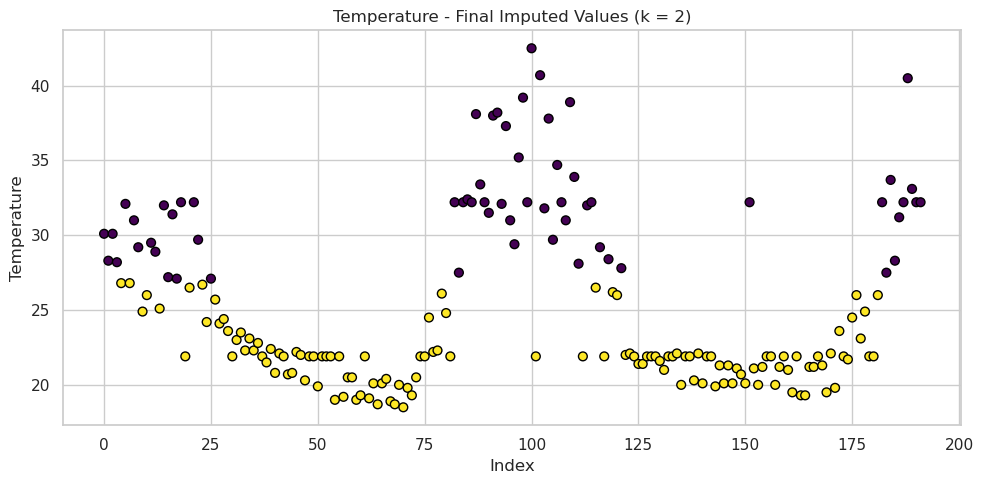

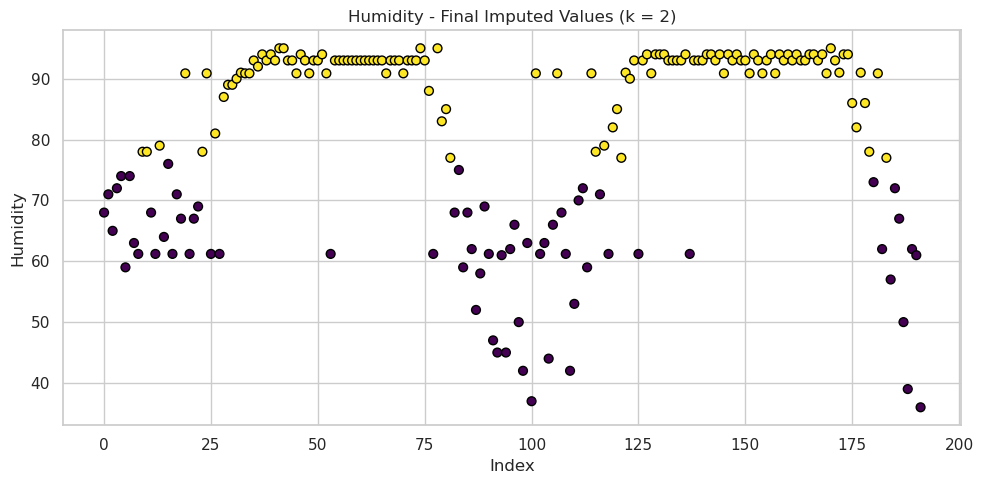

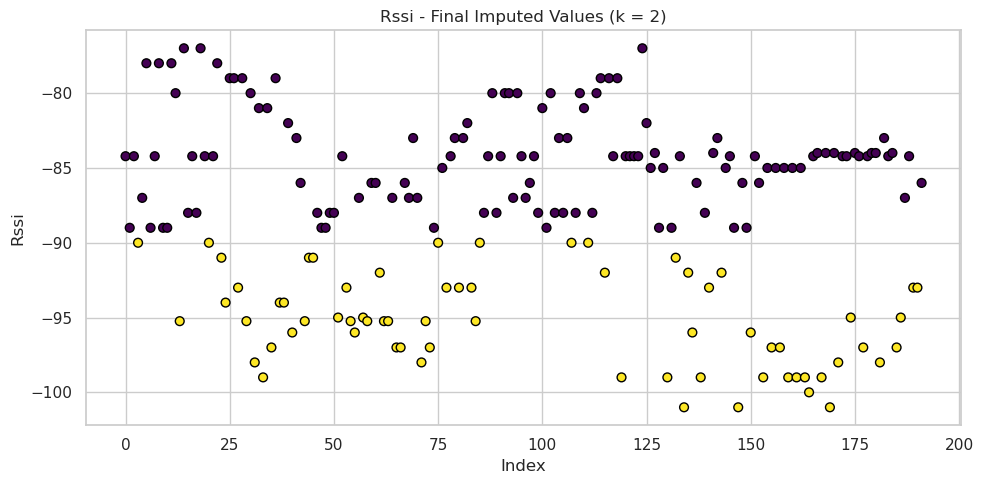

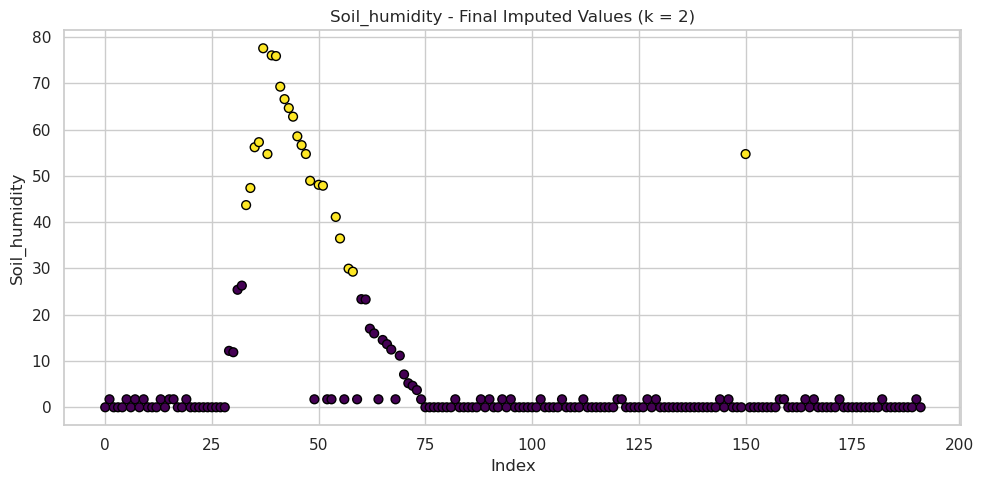


--- Sample: Data with Missing Values ---
   Temperature  Humidity  Rssi  Soil_humidity
0         30.1      68.0   NaN            0.0
1         28.3      71.0 -89.0            NaN
2         30.1      65.0   NaN            0.0
3         28.2      72.0 -90.0            0.0
4         26.8      74.0 -87.0            0.0

--- Sample: Final Imputed Data ---
   Temperature  Humidity       Rssi  Soil_humidity
0         30.1      68.0 -84.214286       0.000000
1         28.3      71.0 -89.000000       1.726742
2         30.1      65.0 -84.214286       0.000000
3         28.2      72.0 -90.000000       0.000000
4         26.8      74.0 -87.000000       0.000000


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Step 1: Introduce missing values ---
def introduce_missing_values(df, missing_rate=0.2, random_state=42):
    np.random.seed(random_state)
    data_array = df.to_numpy().copy()
    n_total = data_array.size
    n_missing = int(missing_rate * n_total)
    flat_indices = np.random.choice(n_total, n_missing, replace=False)
    data_array.ravel()[flat_indices] = np.nan
    missing_mask = np.isnan(data_array)
    return pd.DataFrame(data_array, columns=df.columns), missing_mask

# --- Load dataset ---
data = pd.read_csv("Dataset_scenario_3.csv")
data = data[['Temperature', 'Humidity', 'Rssi', 'Soil_humidity']]
original_data = data.copy()

# --- Only numeric ---
data_numeric = data.select_dtypes(include=[np.number])
df_missing, missing_mask = introduce_missing_values(data_numeric, missing_rate=0.2)
print(f"Missing values per column:\n{df_missing.isna().sum()}")

# --- Step 2: Initial global KNN Imputation ---
initial_imputer = KNNImputer(n_neighbors=5)
df_initial_imputed = pd.DataFrame(initial_imputer.fit_transform(df_missing), columns=df_missing.columns)

# --- Step 3: Column-wise Clustering with Optimal k and KNN Imputation ---
df_clusterwise_imputed = df_missing.copy()
scaler = StandardScaler()
optimal_k_dict = {}

for feature in df_missing.columns:
    print(f"\n🔍 Processing feature: {feature}")

    feature_data = df_initial_imputed[[feature]].copy()
    feature_scaled = scaler.fit_transform(feature_data)

    # Elbow method to find optimal k
    inertias = []
    k_range = range(1, 10)
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init='auto')
        km.fit(feature_scaled)
        inertias.append(km.inertia_)

    # Second derivative method
    diff1 = np.diff(inertias)
    diff2 = np.diff(diff1)
    if len(diff2) > 0:
        elbow_idx = np.argmax(diff2) + 2
        optimal_k = elbow_idx
        print(f"  ✅ Optimal k (elbow): {optimal_k}")
    else:
        optimal_k = 3
        print("  ⚠️ Using default k = 3")

    optimal_k_dict[feature] = optimal_k

    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(feature_scaled)
    df_clusterwise_imputed[f'{feature}_Cluster'] = cluster_labels

    # Impute within each cluster
    for cluster_id in range(optimal_k):
        cluster_indices = df_clusterwise_imputed[df_clusterwise_imputed[f'{feature}_Cluster'] == cluster_id].index
        sub_df = df_clusterwise_imputed.loc[cluster_indices, [feature]]

        if sub_df[feature].isna().sum() == 0:
            continue

        knn = KNNImputer(n_neighbors=3)
        sub_imputed = knn.fit_transform(sub_df)
        df_clusterwise_imputed.loc[cluster_indices, feature] = sub_imputed

# Drop cluster columns
df_clusterwise_imputed = df_clusterwise_imputed[df_missing.columns]

# --- Step 4: Evaluation Metrics (Scaled to [0,1]) ---
scaler = MinMaxScaler()
original_scaled = pd.DataFrame(scaler.fit_transform(original_data), columns=original_data.columns)
imputed_scaled = pd.DataFrame(scaler.transform(df_clusterwise_imputed), columns=df_clusterwise_imputed.columns)

print("\n--- Evaluation Metrics (All Data Points & Only Imputed Entries, Scaled to [0,1]) ---")
for i, feature in enumerate(df_missing.columns):
    y_true_all = original_scaled[feature]
    y_pred_all = imputed_scaled[feature]

    mask = missing_mask[:, i]
    y_true_missing = original_scaled.loc[mask, feature]
    y_pred_missing = imputed_scaled.loc[mask, feature]

    print(f"\n{feature} (Scaled to [0,1]):")
    print(f"  [All]       R² Score: {r2_score(y_true_all, y_pred_all):.4f}")
    print(f"  [All]       MSE: {mean_squared_error(y_true_all, y_pred_all):.4f}")
    print(f"  [All]       MAE: {mean_absolute_error(y_true_all, y_pred_all):.4f}")
    if mask.sum() > 0:
        print(f"  [Missing]   R² Score: {r2_score(y_true_missing, y_pred_missing):.4f}")
        print(f"  [Missing]   MSE: {mean_squared_error(y_true_missing, y_pred_missing):.4f}")
        print(f"  [Missing]   MAE: {mean_absolute_error(y_true_missing, y_pred_missing):.4f}")
    else:
        print("  [Missing]   No imputed values for this feature.")

# --- Step 5: Visualize clustering per feature using optimal k ---
for feature in df_missing.columns:
    feature_data = df_initial_imputed[[feature]].copy()
    feature_scaled = scaler.fit_transform(feature_data)
    k = optimal_k_dict[feature]

    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(feature_scaled)

    plt.figure(figsize=(10, 5))
    plt.scatter(np.arange(len(df_clusterwise_imputed)), df_clusterwise_imputed[feature],
                c=cluster_labels, cmap='viridis', s=40, edgecolor='k')
    plt.title(f'{feature} - Final Imputed Values (k = {k})')
    plt.xlabel('Index')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.grid(True)
    plt.show()

# --- Step 6: Show data previews ---
print("\n--- Sample: Data with Missing Values ---")
print(df_missing.head())

print("\n--- Sample: Final Imputed Data ---")
print(df_clusterwise_imputed.head())
